# Aridity Index (AI)
Extract mean aridity index within a 10 km bounding box for each site.

Source: Zomer et al. (2022) Global Aridity Index v3.1
        https://doi.org/10.6084/m9.figshare.7504448

- Using Annual ETO version (ai_v31_yr.tif) which represents the mean annual aridity index.
- Raw values are stored as uint16 integers multiplied by 10,000.
- Divide by 10,000 to get the actual aridity index.
- Higher values = more humid; lower values = more arid.


These are the libraries that will be used on this script

In [1]:
# Libraries
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import from_bounds
import matplotlib.cm as cm # Package for colors
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
from scipy import stats #spearman rank correlation
from scipy.stats import spearmanr # Using for Spearman Rank Correlation


# CREATE FUNCTION FOR ARIDITY INDEX


# AI for 1 km^2 
- Adding Threshold of 0.6 
    - `< 0.6 Arid`
    - `> 0.6 Humid`


In [7]:
# Retrieving CSV and TIF from Cyberduck
SITES_CSV = "/capstone/aridgw/outputs/1km/gwl_cult_et_1km.csv" 
ARIDITY_TIF = "/capstone/aridgw/raw_data/Global_Aridity_Index/Global-AI_ET0__annual_v3_1/ai_v31_yr.tif"

# CSV being saved in CyberDuck - Using Path
OUTPUT_CSV = "/capstone/aridgw/outputs/1km/site_aridity_1km.csv"

# Size of Bounding Box
BBOX_KM = 1    # side length (km) producing 1km area

AREA_LABEL = "1km"

AI_SCALE = 10_000.0   # raw values are AI * 10000


def km_to_deg(km: float, latitude: float) -> tuple[float, float]:
    """Convert km offset to degrees lat/lon at a given latitude."""
    lat_deg = km / 111.0
    lon_deg = km / (111.0 * np.cos(np.radians(latitude)))
    return lat_deg, lon_deg


def extract_mean_aridity(src: rasterio.DatasetReader, lat: float, lon: float) -> float:
    """Extract mean aridity index within BBOX_KM around a point."""
    half = BBOX_KM / 2
    lat_off, lon_off = km_to_deg(half, lat)

    window = from_bounds(
        left=lon - lon_off,
        bottom=lat - lat_off,
        right=lon + lon_off,
        top=lat + lat_off,
        transform=src.transform
    )
    data = src.read(1, window=window).astype(float)
    data[data == 0] = np.nan  # 0 is nodata in this dataset

    if np.all(np.isnan(data)):
        return np.nan

    return float(np.nanmean(data)) / AI_SCALE


def main():
    df = pd.read_csv(SITES_CSV)
    sites = df[["site_id", "latitude", "longitude"]].drop_duplicates().copy()

    print(f"Extracting AI_{AREA_LABEL} for {len(sites)} sites...")

    with rasterio.open(ARIDITY_TIF) as src:
        sites[f"AI_{AREA_LABEL}"] = sites.apply(
            lambda row: extract_mean_aridity(src, row["latitude"], row["longitude"]),
            axis=1
        )

    
    result = df.merge(sites[["site_id", f"AI_{AREA_LABEL}"]], on="site_id", how="left")
    result["aridity_class"] = np.where(result["AI_1km"] < 0.6, "arid", "humid") # Threshold
    result.to_csv(OUTPUT_CSV, index=False)

    #print(f"Saved: {OUTPUT_CSV}")
    print(result[["site_id", "latitude", "longitude", f"AI_{AREA_LABEL}", "aridity_class"]].drop_duplicates().to_string())



if __name__ == "__main__":
    main()


Extracting AI_1km for 50 sites...
                    site_id  latitude  longitude  AI_1km aridity_class
0      KSGS.371852100505801  37.31502  -100.8505  0.2871          arid
21     KSGS.372043101363101  37.34495  -101.6104  0.2302          arid
42     KSGS.372539100142504  37.42949  -100.2434  0.3153          arid
63     KSGS.373331098033301  37.56096   -98.0580  0.4661          arid
84     KSGS.373607100565301  37.59874  -100.9497  0.2782          arid
105    KSGS.374111099070401  37.68448   -99.1192  0.3797          arid
126    KSGS.374125100344101  37.69024  -100.5795  0.3101          arid
147    KSGS.374747100552101  37.79492  -100.9225  0.2908          arid
168    KSGS.375145100485701  37.86209  -100.8179  0.2917          arid
189    KSGS.375454101075401  37.91572  -101.1306  0.2784          arid
210            TWDB.0753701  35.16000  -102.4886  0.2411          arid
231            TWDB.1005225  34.97000  -102.4381  0.2388          arid
252            TWDB.1038101  34.46000  -102

# Budyko Curve
Integrating 
- Aridity Index (x-axis)
- Groundwater Trend Level (color gradient)
- ET:Precip (y-axis)
- Higher Arid = More GW Decline
- Higer AI = More Humid

### Start by loading in data with ET:Precip, GWL trend meters per year, and Aridity Index

In [3]:
df = pd.read_csv('/capstone/aridgw/outputs/1km/site_summary_1km.csv')

# Checking total rows
print(f'There are', df.shape[0], 'rows')

# View first 5 rows
df.head()


There are 50 rows


,site_id,gw_trend_m_per_yr,region,mean_et,mean_precip,et_precip_ratio
0,KSGS.371852100505801,0.616701,Southern Kansas,797.106238,551.83820,1.444456
1,KSGS.372043101363101,0.213301,Southern Kansas,522.713143,514.42303,1.016115
2,KSGS.372539100142504,1.047972,Southern Kansas,829.910619,605.14417,1.371426
3,KSGS.373331098033301,0.063359,Southern Kansas,860.773810,929.18040,0.926380
4,KSGS.373607100565301,0.595615,Southern Kansas,616.277619,523.98620,1.176133


# Values for Budyko Curve 

In [4]:
print(f'The Max value for ET:Precipitation Ratio is:', df['et_precip_ratio'].max())

print(f'The Min value for ET:Precipitation Ratio is:', df['et_precip_ratio'].min())

# print(f'The Max value for Dryness Index Ratio is:', df['dryness_index'].max())

# print(f'The Min value for Dryness Index Ratio is:', df['dryness_index'].min())




The Max value for ET:Precipitation Ratio is: 6.540061214691386
The Min value for ET:Precipitation Ratio is: 0.5474612918182682


In [5]:
df.head()

,site_id,gw_trend_m_per_yr,region,mean_et,mean_precip,et_precip_ratio
0,KSGS.371852100505801,0.616701,Southern Kansas,797.106238,551.83820,1.444456
1,KSGS.372043101363101,0.213301,Southern Kansas,522.713143,514.42303,1.016115
2,KSGS.372539100142504,1.047972,Southern Kansas,829.910619,605.14417,1.371426
3,KSGS.373331098033301,0.063359,Southern Kansas,860.773810,929.18040,0.926380
4,KSGS.373607100565301,0.595615,Southern Kansas,616.277619,523.98620,1.176133


# Log Scale

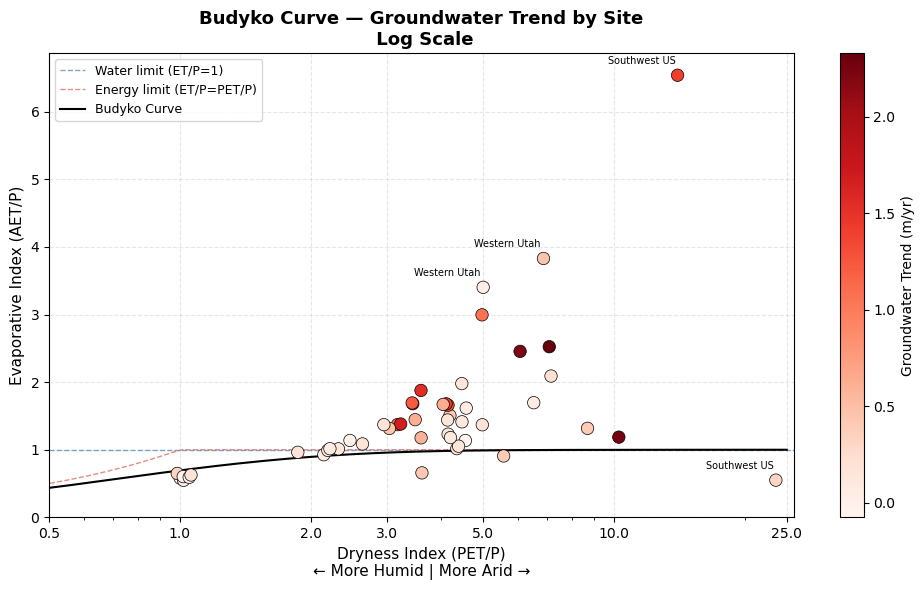

In [6]:
# Add site_summary csv
df = pd.read_csv('/capstone/aridgw/outputs/1km/site_summary_1km.csv')

# Add sites_aridity csv
ai = pd.read_csv('/capstone/aridgw/outputs/1km/sites_aridity_1km.csv')[['site_id', 'AI_1km']].drop_duplicates()

# Left Join
df = df.merge(ai, on='site_id', how='left')

#Dryness Index (PET/P): Inverse of Aridity Index for Budyko x-axis
df['dryness_index'] = 1 / df['AI_1km']

# --- Budyko theoretical curve ---
di_curve = np.linspace(0.01, 25, 500)
budyko_y = np.sqrt((1 - np.exp(-di_curve)) * di_curve * np.tanh(1 / di_curve))

fig, ax = plt.subplots(figsize=(10, 6))

# Theoretical limits
ax.axhline(y=1, color='steelblue', linestyle='--', linewidth=1, alpha=0.7, label='Water limit (ET/P=1)')
ax.plot(di_curve, np.minimum(di_curve, 1), color='#d6604d', linestyle='--', linewidth=1, alpha=0.7, label='Energy limit (ET/P=PET/P)')

# Budyko curve
ax.plot(di_curve, budyko_y, color='black', linewidth=1.5, label='Budyko Curve', zorder=2)

# Scatter
cmap = plt.cm.Reds
sc = ax.scatter(
    df['dryness_index'], df['et_precip_ratio'],
    c=df['gw_trend_m_per_yr'], cmap=cmap,
    vmin=df['gw_trend_m_per_yr'].min(), vmax=df['gw_trend_m_per_yr'].max(),
    s=80, edgecolors='black', linewidths=0.5, zorder=4
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Groundwater Trend (m/yr)', fontsize=10)

# Outlier labels
outliers = df[(df['et_precip_ratio'] > 3.0) | (df['dryness_index'] > 15)]
for _, row in outliers.iterrows():
    ax.annotate(row['region'],
                xy=(row['dryness_index'], row['et_precip_ratio']),
                xytext=(-50, 8), textcoords='offset points',
                fontsize=7, color='black')

# Log scale x-axis
ax.set_xscale('log')
ax.set_xlim(0.5, df['dryness_index'].max() * 1.1)

ax.set_xticks([0.5, 1, 2, 3, 5, 10, 25])

ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

ax.set_ylim(0, df['et_precip_ratio'].max() * 1.05)
ax.set_xlabel('Dryness Index (PET/P)\n← More Humid | More Arid →', fontsize=11)
ax.set_ylabel('Evaporative Index (AET/P)', fontsize=11)
ax.set_title('Budyko Curve — Groundwater Trend by Site\n Log Scale', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('budyko_curve_xlog.png', dpi=150)
plt.show()